In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df= pd.read_csv("demand_forecasting.csv")

In [19]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Data Filtering 

In [20]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [21]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [22]:
df["Date"]

0        2022-01-01
1        2022-01-01
2        2022-01-01
3        2022-01-01
4        2022-01-01
            ...    
75995    2024-01-30
75996    2024-01-30
75997    2024-01-30
75998    2024-01-30
75999    2024-01-30
Name: Date, Length: 76000, dtype: object

In [23]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [24]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,30,Tuesday


In [25]:
df["Discounted Price"]=df["Price"]*(1-df["Discount"]/100)

In [26]:
df["Units Sold Ratio"]=df["Units Sold"]/df["Inventory Level"]

In [27]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Units Sold Ratio
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


## Analysis

In [28]:
df.groupby("Category")["Demand"].agg(["mean","sum","std"]).sort_values(by="mean", ascending=False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Electronics,97.482018,889036,40.557859
Toys,92.606955,985338,46.170390
Furniture,73.581140,1006590,32.336141


In [29]:
df.groupby(["Region","Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [30]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

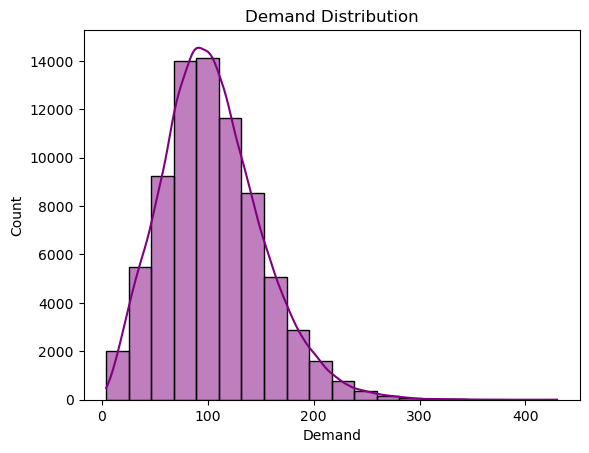

In [31]:
sns.histplot(df["Demand"],bins=20,kde=True,color="purple")
plt.title("Demand Distribution")
plt.show()

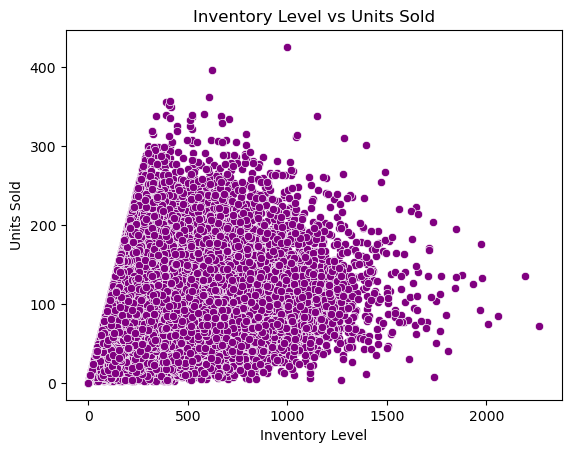

In [32]:
sns.scatterplot(data=df,x="Inventory Level",y="Units Sold",color="purple")
plt.title("Inventory Level vs Units Sold")
plt.show()

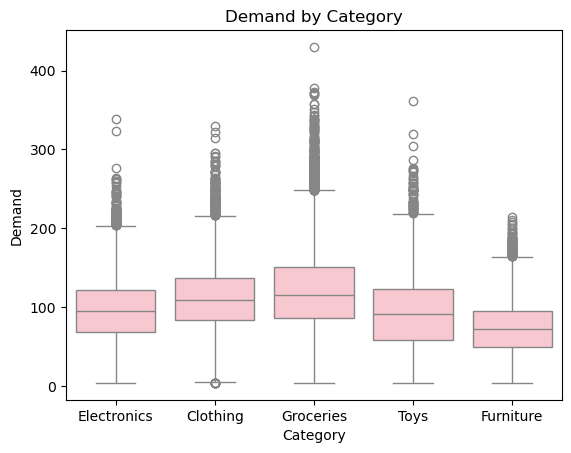

In [33]:
sns.boxplot(data=df,x="Category",y="Demand",color="pink")
plt.title("Demand by Category")
plt.show()

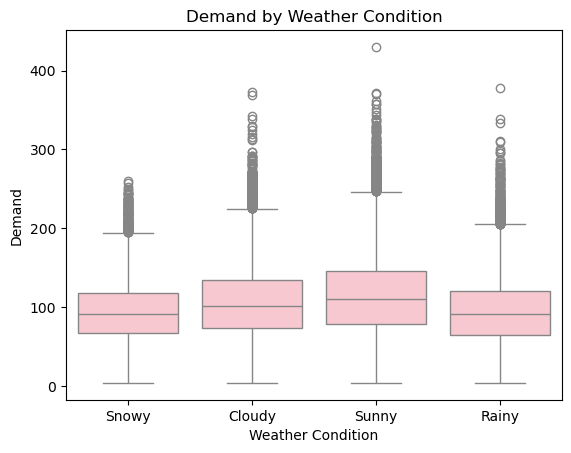

In [34]:
sns.boxplot(data=df,x="Weather Condition",y="Demand",color="pink")
plt.title("Demand by Weather Condition")
plt.show()

### Time Series Analysis

In [35]:
monthly_demand=df.groupby("Month")["Demand"].mean()

In [36]:
monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

Text(0.5, 1.0, 'Average Demand by Month')

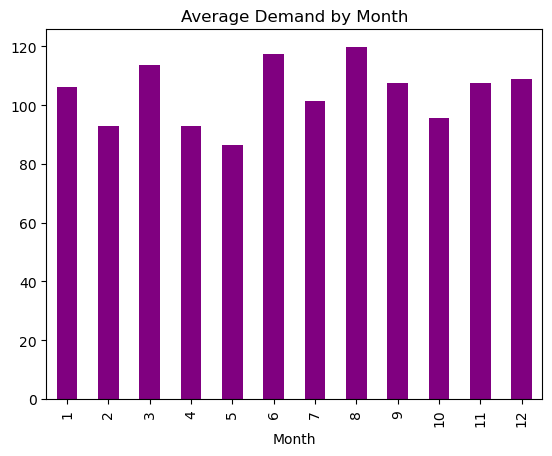

In [37]:
monthly_demand.plot(kind="bar",color="purple")
plt.title("Average Demand by Month")

In [38]:
daily_demand=df.groupby("Date")["Demand"].sum()

Text(0.5, 0, 'Date')

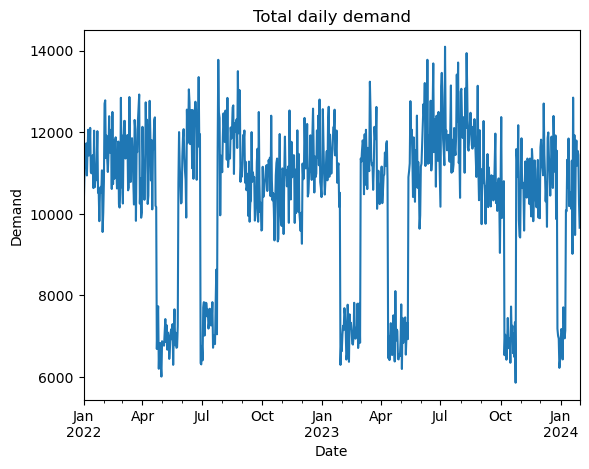

In [39]:
daily_demand.plot()
plt.title("Total daily demand")
plt.ylabel("Demand")
plt.xlabel("Date")

Text(0.5, 1.0, 'Promotion Impact on Demand')

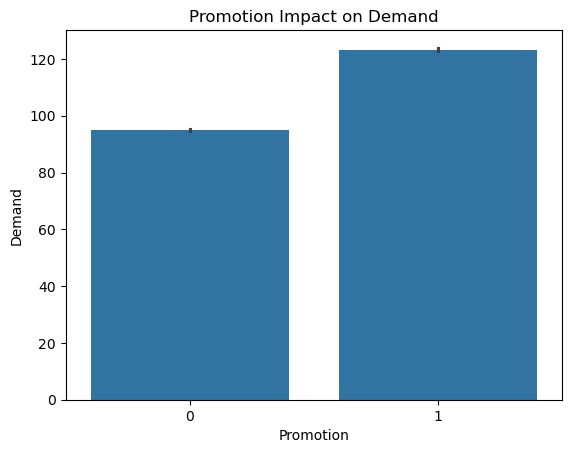

In [40]:
sns.barplot(data=df,x="Promotion",y="Demand")
plt.title("Promotion Impact on Demand")

<Axes: title={'center': 'Demand by Seasonality'}, xlabel='Seasonality'>

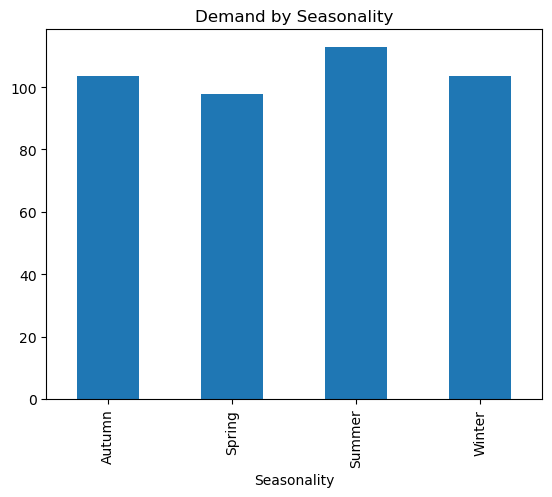

In [41]:
df.groupby("Seasonality")["Demand"].mean().plot(kind="bar",title="Demand by Seasonality")

In [42]:
df = df.sort_values("Date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

assert train["Date"].max() < test["Date"].min()

In [43]:
train_daily = train.groupby("Date")["Demand"].sum()
test_daily  = test.groupby("Date")["Demand"].sum()
train_daily
test_daily




Date
2023-09-01    11096
2023-09-02     9745
2023-09-03    11039
2023-09-04    10748
2023-09-05    12272
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 152, dtype: int64

# Conditions Model (Demand by Features)

In [44]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{name:<22} MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

    
df_feat = df.copy()

encoders = {}
for col in ["Category", "Region", "Weather Condition", "Seasonality"]:
    le = LabelEncoder()
    df_feat[col + "_enc"] = le.fit_transform(df_feat[col])
    encoders[col] = le

feature_cols = ["Price", "Discount", "Inventory Level", "Promotion", "Competitor Pricing",
                 "Category_enc", "Region_enc", "Weather Condition_enc", "Seasonality_enc"]

X = df_feat[feature_cols]
y = df_feat["Demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
evaluate(y_test, baseline_pred, "Baseline (global mean)")

cat_means = df_feat.loc[X_train.index].groupby("Category")["Demand"].mean()
category_baseline_pred = df_feat.loc[X_test.index, "Category"].map(cat_means)
evaluate(y_test, category_baseline_pred, "Baseline (category mean)")

Baseline (global mean) MAE=36.78  RMSE=46.73  MAPE=56.17%
Baseline (category mean) MAE=34.19  RMSE=43.35  MAPE=50.23%


In [60]:
rf_feat = RandomForestRegressor(n_estimators=300, random_state=42)
rf_feat.fit(X_train, y_train)
evaluate(y_test, rf_feat.predict(X_test), "Random Forest (features)")

Random Forest (features) MAE=22.32  RMSE=31.81  MAPE=30.94%


In [61]:
importances = pd.Series(rf_feat.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

Price                    0.329690
Category_enc             0.141880
Competitor Pricing       0.133024
Inventory Level          0.132674
Promotion                0.079629
Region_enc               0.065323
Discount                 0.047903
Seasonality_enc          0.037664
Weather Condition_enc    0.032214
dtype: float64


In [62]:
df_feat.loc[X_test.index, "Demand"].describe()

count    15200.000000
mean       104.796053
std         46.730357
min          4.000000
25%         72.000000
50%        101.000000
75%        133.000000
max        373.000000
Name: Demand, dtype: float64

In [64]:
final_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
final_rf.fit(X, y)

evaluate(y, final_rf.predict(X), "Final model (bounded, in-sample check)")


joblib.dump(final_rf, "rf_demand_model.pkl", compress=3)
joblib.dump(feature_cols, "model_features.pkl")
joblib.dump(encoders, "label_encoders.pkl")

Final model (bounded, in-sample check) MAE=16.44  RMSE=23.02  MAPE=23.76%


['label_encoders.pkl']

In [67]:
category_avg_demand = df_feat.groupby("Category")["Demand"].mean().to_dict()
joblib.dump(category_avg_demand, "category_avg_demand.pkl")

['category_avg_demand.pkl']

In [66]:
#a check
final_rf_check = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
final_rf_check.fit(X_train, y_train)
evaluate(y_test, final_rf_check.predict(X_test), "Bounded model (true test-set check)")

Bounded model (true test-set check) MAE=23.01  RMSE=31.87  MAPE=31.92%
